In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('customer_churn_dataset.csv')

In [3]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [4]:
print("="*60)
print("First 5 Records")
print("="*60)

print(df.head())

print("\n")

print("="*60)
print("Last 5 Records")
print("="*60)

print(df.tail())

print("\n")

print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Column Names")
print("="*60)

print(df.columns)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

print("\n")

print("="*60)
print("Data Types")
print("="*60)

print(df.dtypes)


First 5 Records
   CustomerID  Age  Gender  Tenure  Usage Frequency  Support Calls  \
0           1   22  Female      25               14              4   
1           2   41  Female      28               28              7   
2           3   47    Male      27               10              2   
3           4   35    Male       9               12              5   
4           5   53  Female      58               24              9   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0             27             Basic         Monthly          598   
1             13          Standard         Monthly          584   
2             29           Premium          Annual          757   
3             17           Premium       Quarterly          232   
4              2          Standard          Annual          533   

   Last Interaction  Churn  
0                 9      1  
1                20      0  
2                21      0  
3                18      0  
4              

In [5]:
print("\n")

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())



Missing Values
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [6]:
print("\n")

print("="*60)
print("Duplicate Records")
print("="*60)

print(df.duplicated().sum())



Duplicate Records
0


In [7]:
print("\n")

print("="*60)
print("Statistical Summary")
print("="*60)

print(df.describe())



Statistical Summary
         CustomerID           Age        Tenure  Usage Frequency  \
count  64374.000000  64374.000000  64374.000000     64374.000000   
mean   32187.500000     41.970982     31.994827        15.080234   
std    18583.317451     13.924911     17.098234         8.816470   
min        1.000000     18.000000      1.000000         1.000000   
25%    16094.250000     30.000000     18.000000         7.000000   
50%    32187.500000     42.000000     33.000000        15.000000   
75%    48280.750000     54.000000     47.000000        23.000000   
max    64374.000000     65.000000     60.000000        30.000000   

       Support Calls  Payment Delay   Total Spend  Last Interaction  \
count   64374.000000   64374.000000  64374.000000      64374.000000   
mean        5.400690      17.133952    541.023379         15.498850   
std         3.114005       8.852211    260.874809          8.638436   
min         0.000000       0.000000    100.000000          1.000000   
25%       

In [8]:
from pandas.api.types import (
    is_string_dtype,
    is_integer_dtype,
    is_float_dtype
)

categorical_columns = []
numerical_columns = []

for col in df.columns:

    if is_string_dtype(df[col]):

        categorical_columns.append(col)

    elif is_integer_dtype(df[col]) or is_float_dtype(df[col]):

        numerical_columns.append(col)

print("\n")

print("="*60)
print("Categorical Columns")
print("="*60)

print(categorical_columns)

print("\n")

print("="*60)
print("Numerical Columns")
print("="*60)

print(numerical_columns)




Categorical Columns
['Gender', 'Subscription Type', 'Contract Length']


Numerical Columns
['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']


In [9]:
for col in categorical_columns:

    print("\n")

    print("="*60)
    print(col.upper())
    print("="*60)

    print(df[col].value_counts())



GENDER
Gender
Female    34353
Male      30021
Name: count, dtype: int64


SUBSCRIPTION TYPE
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64


CONTRACT LENGTH
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64




Target Distribution
Churn
0    33881
1    30493
Name: count, dtype: int64


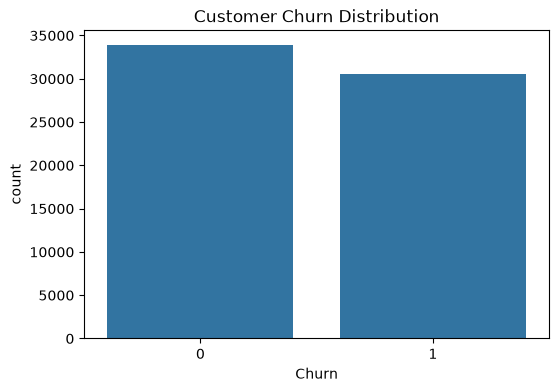

In [10]:
print("\n")

print("="*60)
print("Target Distribution")
print("="*60)

print(df["Churn"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(

    data=df,

    x="Churn"

)

plt.title("Customer Churn Distribution")

plt.show()


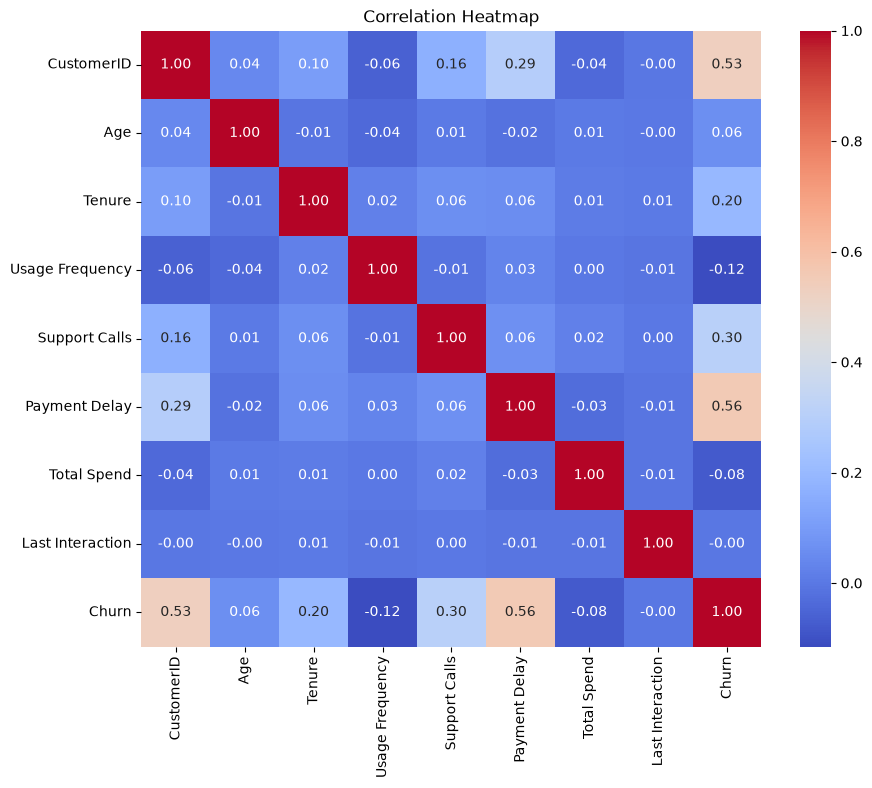

In [11]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(

    correlation,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Heatmap")

plt.show()


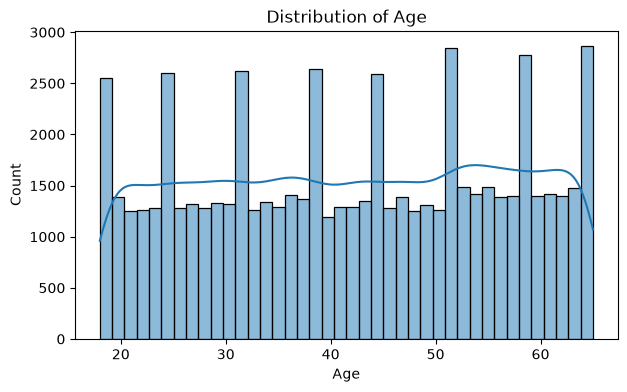

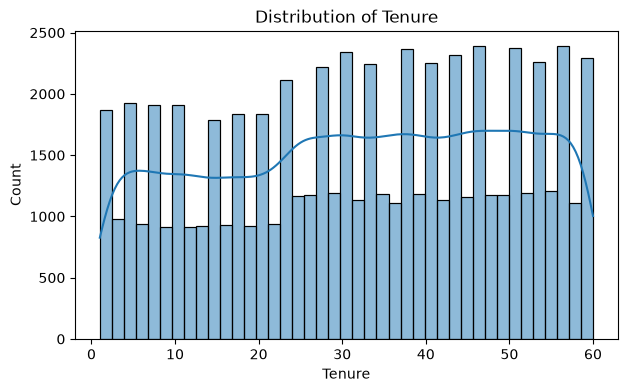

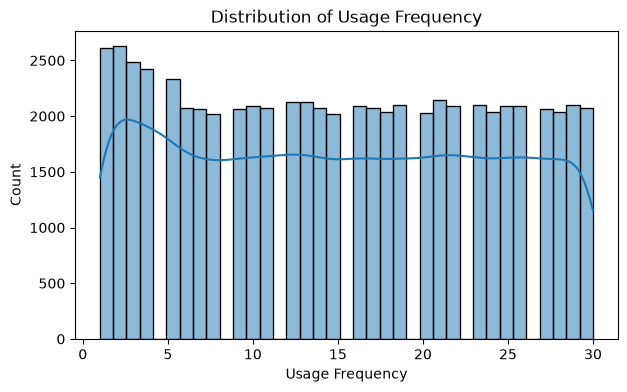

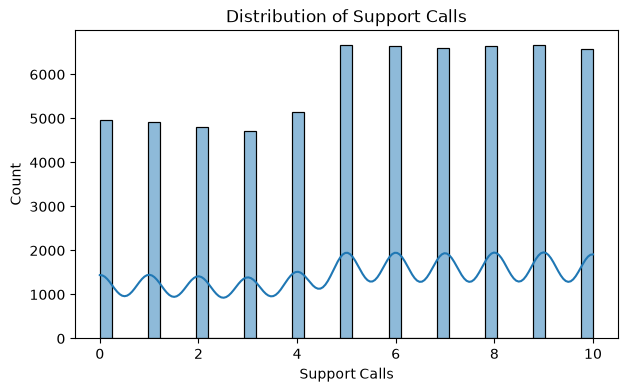

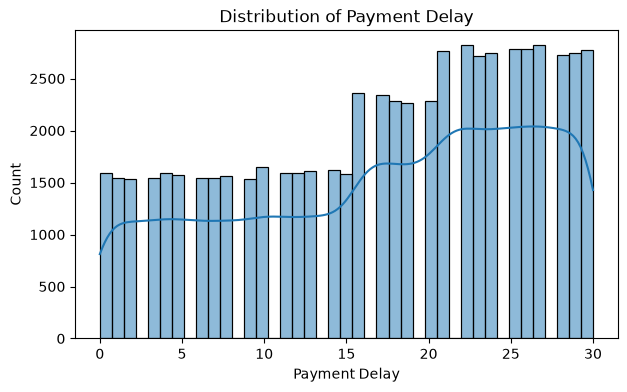

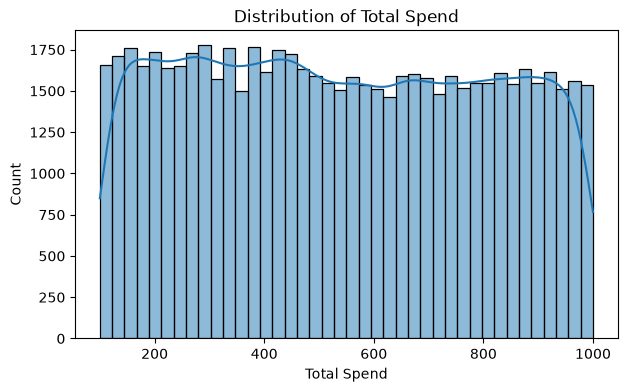

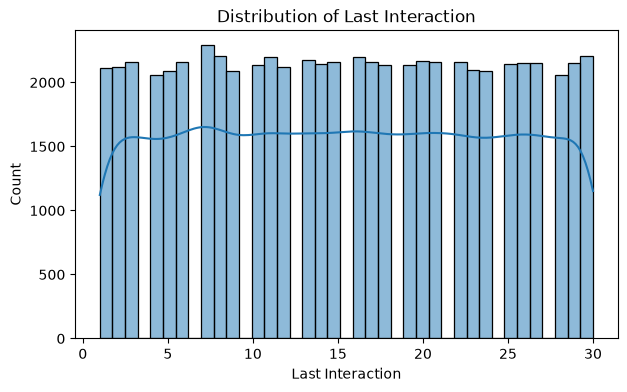

In [12]:
numerical_features = [

    "Age",

    "Tenure",

    "Usage Frequency",

    "Support Calls",

    "Payment Delay",

    "Total Spend",

    "Last Interaction"

]

for feature in numerical_features:

    plt.figure(figsize=(7,4))

    sns.histplot(

        df[feature],

        kde=True

    )

    plt.title(f"Distribution of {feature}")

    plt.show()


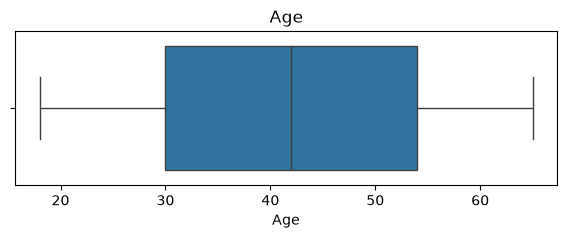

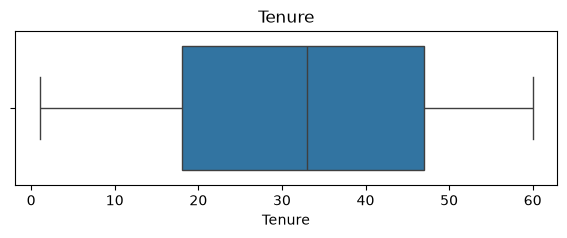

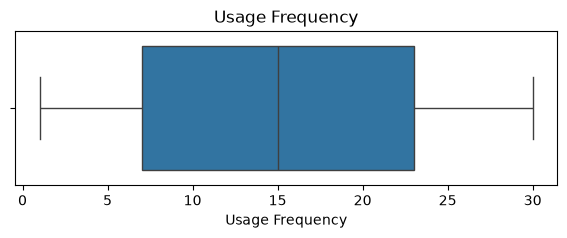

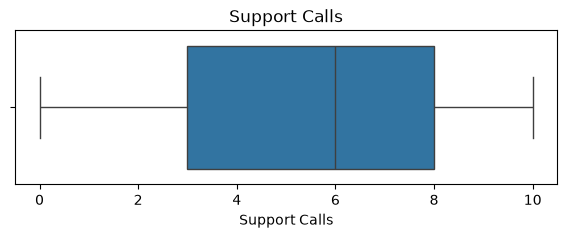

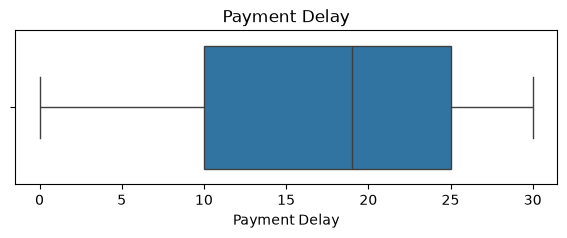

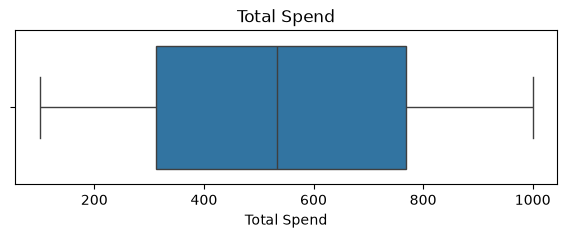

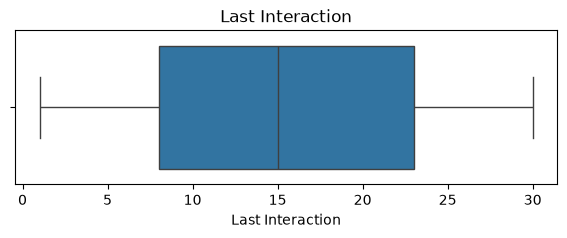

In [13]:
for feature in numerical_features:

    plt.figure(figsize=(7,2))

    sns.boxplot(

        x=df[feature]

    )

    plt.title(feature)

    plt.show()

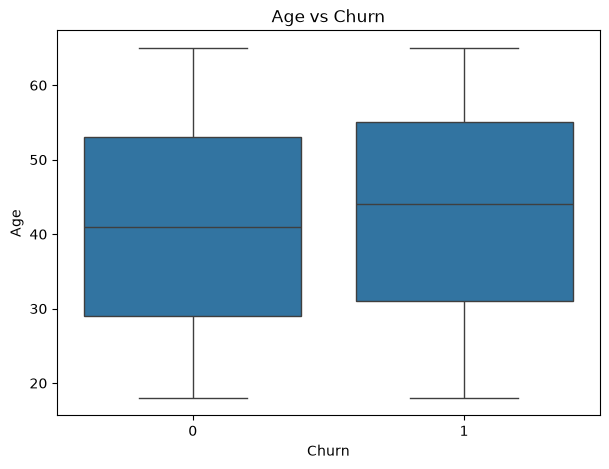

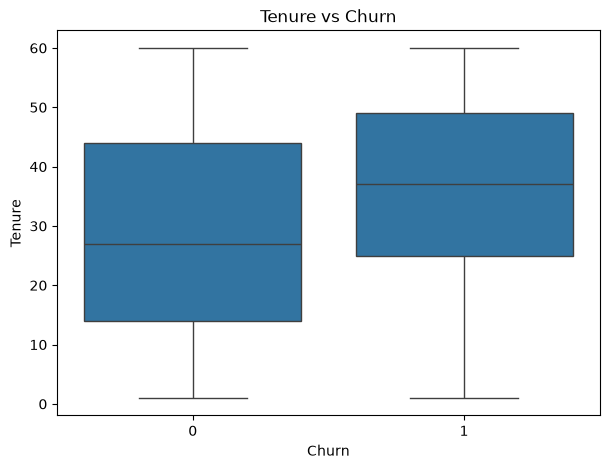

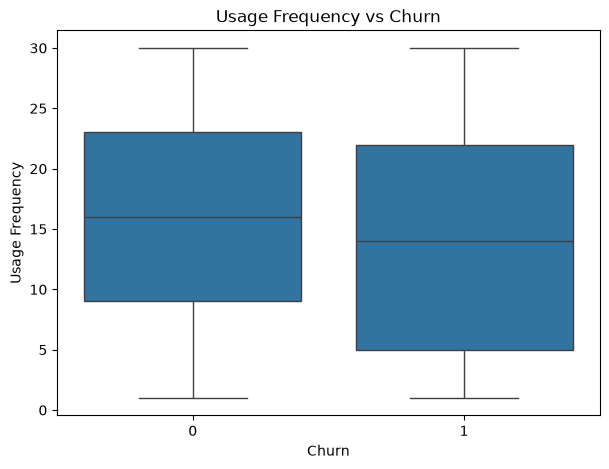

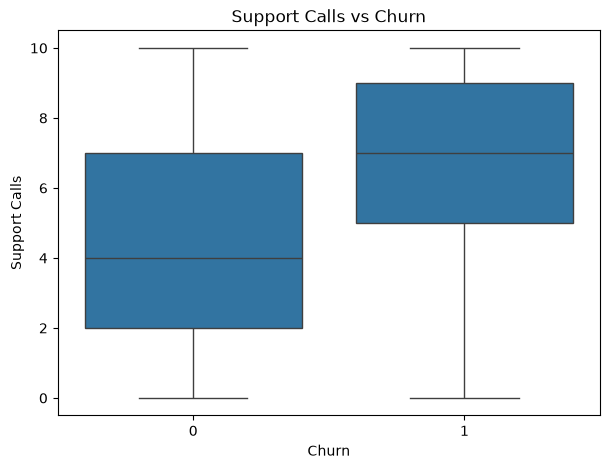

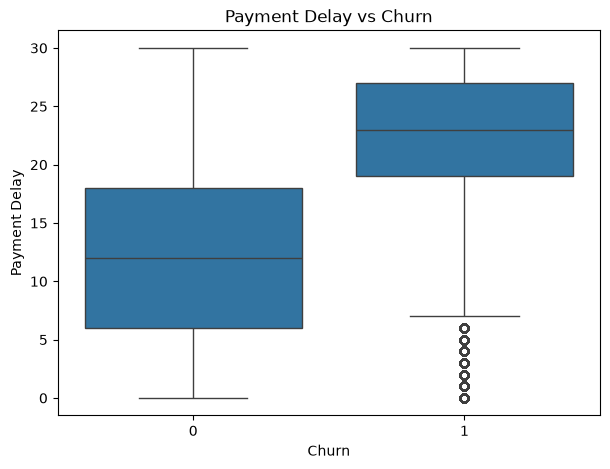

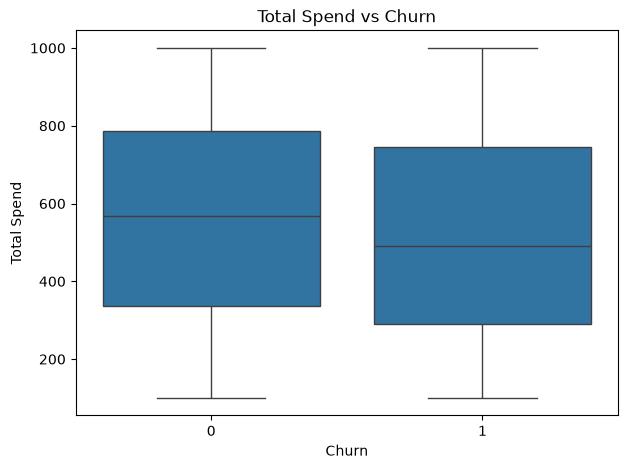

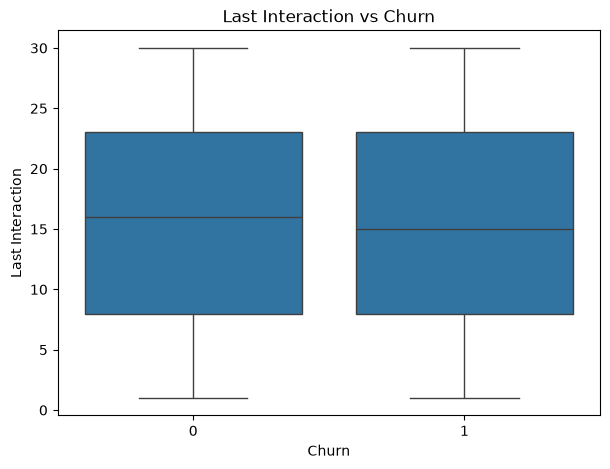

In [14]:
for feature in numerical_features:

    plt.figure(figsize=(7,5))

    sns.boxplot(

        data=df,

        x="Churn",

        y=feature

    )

    plt.title(f"{feature} vs Churn")

    plt.show()

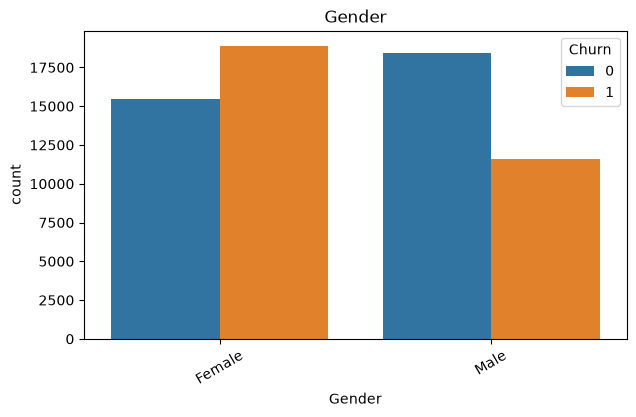

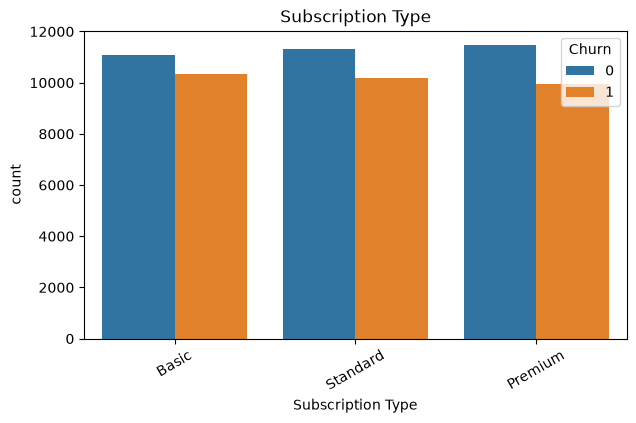

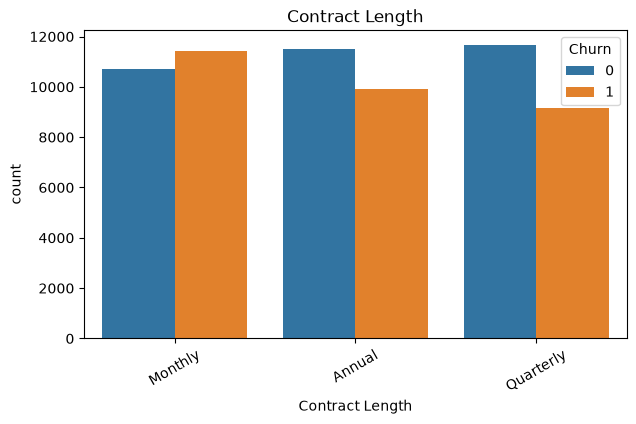

In [15]:
categorical_features = [

    "Gender",

    "Subscription Type",

    "Contract Length"

]

for feature in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(

        data=df,

        x=feature,

        hue="Churn"

    )

    plt.xticks(rotation=30)

    plt.title(feature)

    plt.show()


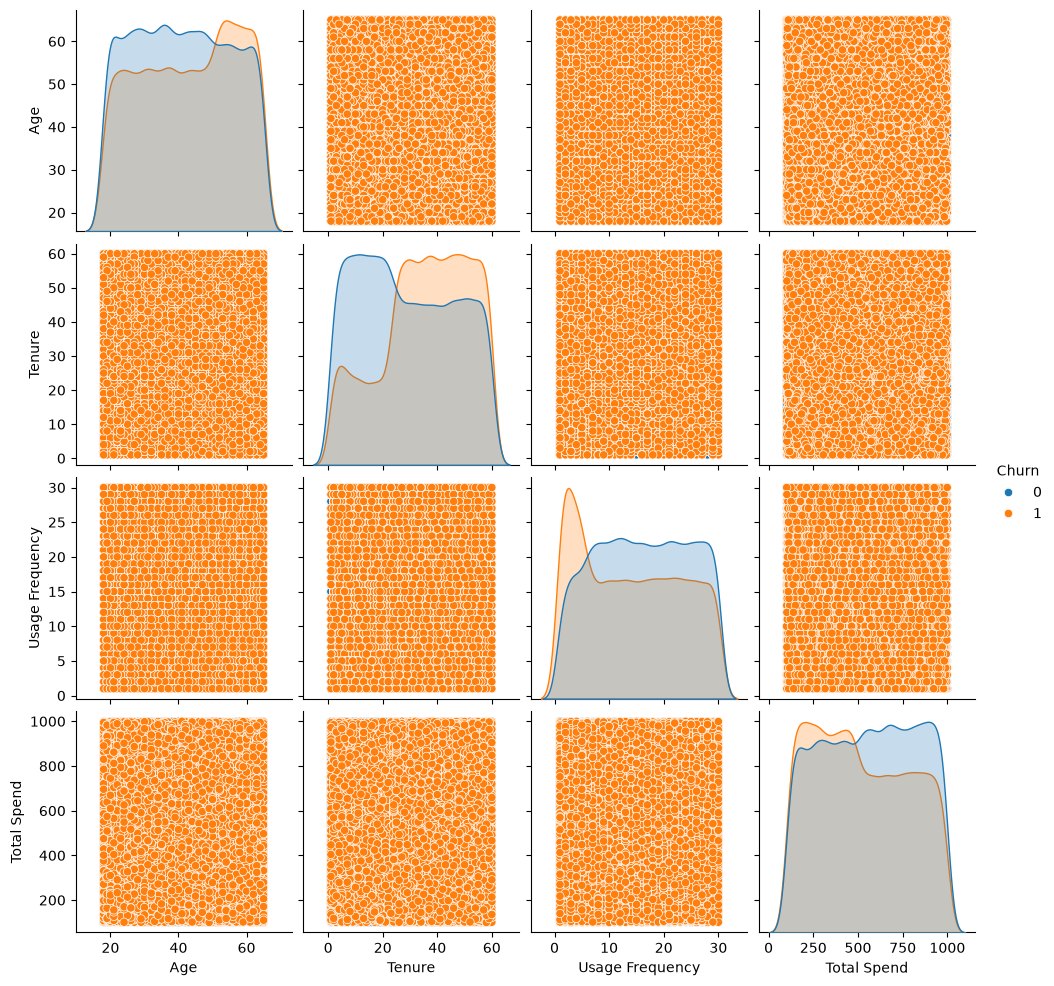

In [16]:
sns.pairplot(

    df[

        [

            "Age",

            "Tenure",

            "Usage Frequency",

            "Total Spend",

            "Churn"

        ]

    ],

    hue="Churn"

)

plt.show()


In [17]:
X = df.drop(

    columns=[

        "CustomerID",

        "Churn"

    ]

)

In [19]:
y = df["Churn"]

print("\n")

print("="*60)
print("Input Features")
print("="*60)

print(X.head())

print("\n")

print("="*60)
print("Target")
print("="*60)

print(y.head())

print("\n")

print("Input Shape :", X.shape)

print("Target Shape:", y.shape)

print("\n")






Input Features
   Age  Gender  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0   22  Female      25               14              4             27   
1   41  Female      28               28              7             13   
2   47    Male      27               10              2             29   
3   35    Male       9               12              5             17   
4   53  Female      58               24              9              2   

  Subscription Type Contract Length  Total Spend  Last Interaction  
0             Basic         Monthly          598                 9  
1          Standard         Monthly          584                20  
2           Premium          Annual          757                21  
3           Premium       Quarterly          232                18  
4          Standard          Annual          533                18  


Target
0    1
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64


Input Shape : (64374, 10)
Target Shape: (64374,)




In [20]:
categorical_features = [

    "Gender",

    "Subscription Type",

    "Contract Length"

]

df_encoded = pd.get_dummies(

    df,

    columns=categorical_features,

    drop_first=True,

    dtype=int

)

print("="*60)
print("Encoded Dataset")
print("="*60)

print(df_encoded.head())

print("\n")

print("Dataset Shape :", df_encoded.shape)


Encoded Dataset
   CustomerID  Age  Tenure  Usage Frequency  Support Calls  Payment Delay  \
0           1   22      25               14              4             27   
1           2   41      28               28              7             13   
2           3   47      27               10              2             29   
3           4   35       9               12              5             17   
4           5   53      58               24              9              2   

   Total Spend  Last Interaction  Churn  Gender_Male  \
0          598                 9      1            0   
1          584                20      0            0   
2          757                21      0            1   
3          232                18      0            1   
4          533                18      0            0   

   Subscription Type_Premium  Subscription Type_Standard  \
0                          0                           0   
1                          0                           1   
2   

In [21]:
X = df_encoded.drop(

    columns=[

        "CustomerID",

        "Churn"

    ]

)

y = df_encoded["Churn"]

print("\n")

print("="*60)
print("Feature Matrix")
print("="*60)

print(X.head())

print("\n")

print("="*60)
print("Target Variable")
print("="*60)

print(y.head())




Feature Matrix
   Age  Tenure  Usage Frequency  Support Calls  Payment Delay  Total Spend  \
0   22      25               14              4             27          598   
1   41      28               28              7             13          584   
2   47      27               10              2             29          757   
3   35       9               12              5             17          232   
4   53      58               24              9              2          533   

   Last Interaction  Gender_Male  Subscription Type_Premium  \
0                 9            0                          0   
1                20            0                          0   
2                21            1                          1   
3                18            1                          1   
4                18            0                          0   

   Subscription Type_Standard  Contract Length_Monthly  \
0                           0                        1   
1                  

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\n")

print("="*60)
print("Training Data")
print("="*60)

print(X_train.shape)

print(y_train.shape)

print("\n")

print("="*60)
print("Testing Data")
print("="*60)

print(X_test.shape)

print(y_test.shape)




Training Data
(51499, 12)
(51499,)


Testing Data
(12875, 12)
(12875,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed!")


Feature Scaling Completed!


In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(

    max_iter=1000,

    random_state=42

)

In [25]:
model.fit(

    X_train_scaled,

    y_train

)

print("\nModel Training Completed Successfully!")



Model Training Completed Successfully!


In [26]:
y_pred = model.predict(

    X_test_scaled

)


In [27]:
y_prob = model.predict_proba(

    X_test_scaled

)

print("\n")

print("="*60)
print("Predicted Classes")
print("="*60)

print(y_pred[:10])

print("\n")

print("="*60)
print("Prediction Probabilities")
print("="*60)

print(y_prob[:10])



Predicted Classes
[0 0 0 0 0 0 0 0 0 0]


Prediction Probabilities
[[0.98442457 0.01557543]
 [0.93748898 0.06251102]
 [0.91142685 0.08857315]
 [0.92628523 0.07371477]
 [0.8525986  0.1474014 ]
 [0.98148512 0.01851488]
 [0.89922474 0.10077526]
 [0.9930277  0.0069723 ]
 [0.9077881  0.0922119 ]
 [0.79282718 0.20717282]]


In [28]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score

)

accuracy = accuracy_score(

    y_test,

    y_pred

)

precision = precision_score(

    y_test,

    y_pred

)

recall = recall_score(

    y_test,

    y_pred

)

f1 = f1_score(

    y_test,

    y_pred

)

print("\n")

print("="*60)
print("Model Performance")
print("="*60)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")




Model Performance
Accuracy  : 0.8271
Precision : 0.8136
Recall    : 0.8237
F1 Score  : 0.8186


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("model", LogisticRegression(

        max_iter=1000,

        random_state=42

    ))

])

cv_scores = cross_val_score(

    pipeline,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

print("\n")

print("="*60)
print("Cross Validation")
print("="*60)

print("Fold Scores")

print(cv_scores)

print("\nAverage Accuracy")

print(cv_scores.mean())




Cross Validation
Fold Scores
[0.82998058 0.82943689 0.82601942 0.82539806 0.82173373]

Average Accuracy
0.826513735669544


In [30]:
coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_[0]

})

coefficients["Absolute Coefficient"] = abs(

    coefficients["Coefficient"]

)

coefficients = coefficients.sort_values(

    by="Absolute Coefficient",

    ascending=False

)

print("\n")

print("="*60)
print("Feature Importance")
print("="*60)

print(coefficients)




Feature Importance
                       Feature  Coefficient  Absolute Coefficient
4                Payment Delay     1.892840              1.892840
3                Support Calls     1.035221              1.035221
1                       Tenure     0.597749              0.597749
7                  Gender_Male    -0.569239              0.569239
2              Usage Frequency    -0.523590              0.523590
0                          Age     0.271585              0.271585
5                  Total Spend    -0.258496              0.258496
10     Contract Length_Monthly     0.160581              0.160581
11   Contract Length_Quarterly    -0.079196              0.079196
8    Subscription Type_Premium    -0.048364              0.048364
9   Subscription Type_Standard    -0.030270              0.030270
6             Last Interaction    -0.005282              0.005282


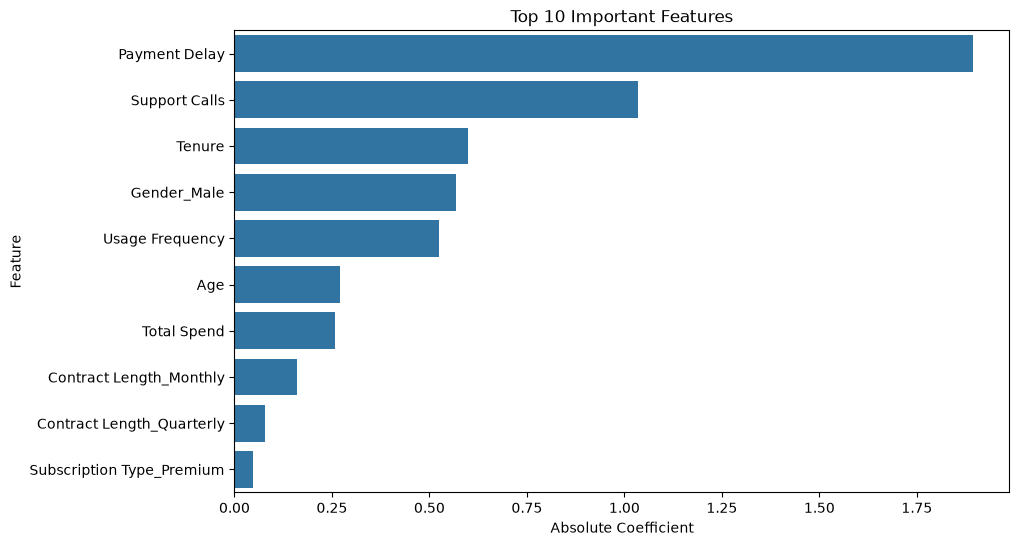

In [31]:
top10 = coefficients.head(10)

plt.figure(figsize=(10,6))

sns.barplot(

    data=top10,

    x="Absolute Coefficient",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.xlabel("Absolute Coefficient")

plt.ylabel("Feature")

plt.show()

In [32]:
print("\n")

print("="*60)
print("Logistic Regression Summary")
print("="*60)

print(f"Training Samples       : {len(X_train)}")

print(f"Testing Samples        : {len(X_test)}")

print(f"Total Features         : {X_train.shape[1]}")

print(f"\nAccuracy              : {accuracy:.4f}")

print(f"Precision             : {precision:.4f}")

print(f"Recall                : {recall:.4f}")

print(f"F1 Score              : {f1:.4f}")

print(f"Cross Validation      : {cv_scores.mean():.4f}")




Logistic Regression Summary
Training Samples       : 51499
Testing Samples        : 12875
Total Features         : 12

Accuracy              : 0.8271
Precision             : 0.8136
Recall                : 0.8237
F1 Score              : 0.8186
Cross Validation      : 0.8265


Confusion Matrix
[[5625 1151]
 [1075 5024]]


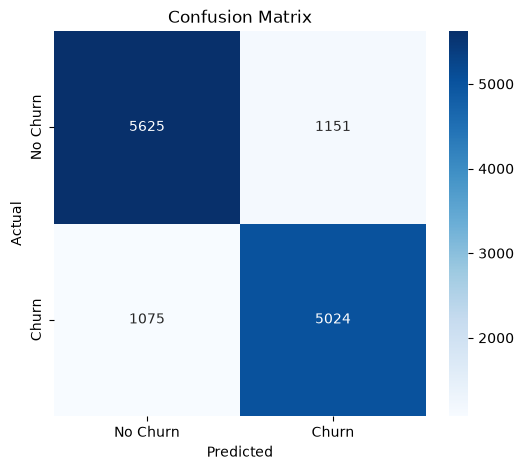

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    y_pred

)

print("="*60)
print("Confusion Matrix")
print("="*60)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["No Churn", "Churn"],

    yticklabels=["No Churn", "Churn"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


In [34]:
from sklearn.metrics import classification_report

print("\n")

print("="*60)
print("Classification Report")
print("="*60)

print(

    classification_report(

        y_test,

        y_pred

    )

)




Classification Report
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



In [35]:
from sklearn.metrics import (

    roc_curve,

    roc_auc_score

)

In [36]:
y_prob_positive = y_prob[:,1]

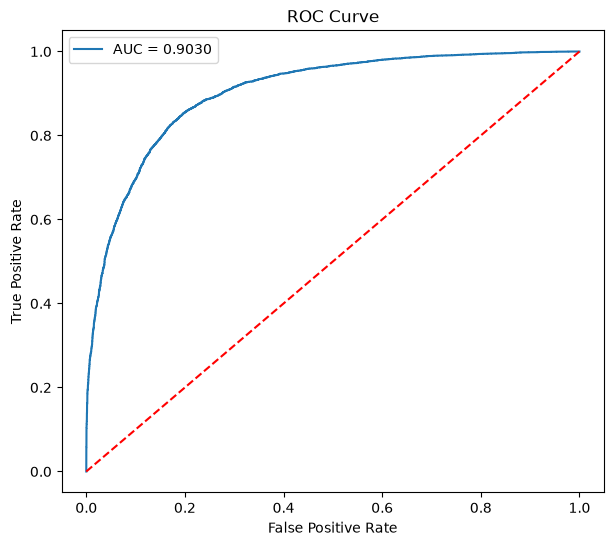



ROC AUC Score
0.9029997562841994


In [37]:
fpr, tpr, thresholds = roc_curve(

    y_test,

    y_prob_positive

)

auc_score = roc_auc_score(

    y_test,

    y_prob_positive

)

plt.figure(figsize=(7,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc_score:.4f}"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="red"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("\n")

print("="*60)
print("ROC AUC Score")
print("="*60)

print(auc_score)

In [38]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

print("\n")

print("="*60)
print("Sample Predictions")
print("="*60)

print(comparison.head(15))




Sample Predictions
    Actual  Predicted
0        0          0
1        1          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       1          1
11       0          0
12       1          1
13       0          0
14       0          0


In [39]:
new_customer = pd.DataFrame({

    "Age":[35],

    "Tenure":[24],

    "Usage Frequency":[18],

    "Support Calls":[2],

    "Payment Delay":[5],

    "Total Spend":[650],

    "Last Interaction":[10],

    "Gender_Male":[1],

    "Subscription Type_Premium":[0],

    "Subscription Type_Standard":[1],

    "Contract Length_Monthly":[1],

    "Contract Length_Quarterly":[0]

})


In [40]:
new_customer_scaled = scaler.transform(

    new_customer

)


In [41]:
prediction = model.predict(

    new_customer_scaled

)

In [42]:
prediction_probability = model.predict_proba(

    new_customer_scaled

)

print("\n")

print("="*60)
print("Prediction for New Customer")
print("="*60)

print("Predicted Class :", prediction[0])

if prediction[0] == 0:

    print("Customer is likely to Stay.")

else:

    print("Customer is likely to Churn.")

print("\nPrediction Probability")

print(prediction_probability)



Prediction for New Customer
Predicted Class : 0
Customer is likely to Stay.

Prediction Probability
[[0.99392096 0.00607904]]


In [43]:
from joblib import dump

dump(

    model,

    "logistic_regression_model.joblib"

)

dump(

    scaler,

    "standard_scaler.joblib"

)

print("\nModel Saved Successfully!")



Model Saved Successfully!


In [44]:
from joblib import load

loaded_model = load(

    "logistic_regression_model.joblib"

)

loaded_scaler = load(

    "standard_scaler.joblib"

)

print("Saved Model Loaded Successfully!")

Saved Model Loaded Successfully!


In [45]:
loaded_prediction = loaded_model.predict(

    loaded_scaler.transform(new_customer)

)

print("\nPrediction Using Loaded Model")

print(loaded_prediction)


Prediction Using Loaded Model
[0]


In [46]:

print("\n")
print("="*70)
print("Customer Churn Prediction using Logistic Regression")
print("="*70)

print(f"Training Samples           : {len(X_train)}")

print(f"Testing Samples            : {len(X_test)}")

print(f"Total Features             : {X_train.shape[1]}")

print(f"\nAccuracy                  : {accuracy:.4f}")

print(f"Precision                 : {precision:.4f}")

print(f"Recall                    : {recall:.4f}")

print(f"F1 Score                  : {f1:.4f}")

print(f"ROC AUC Score             : {auc_score:.4f}")

print(f"Cross Validation Accuracy : {cv_scores.mean():.4f}")

print("\nModel Status : Ready for Deployment")

print("="*70)

print("\nProject Completed Successfully!")



Customer Churn Prediction using Logistic Regression
Training Samples           : 51499
Testing Samples            : 12875
Total Features             : 12

Accuracy                  : 0.8271
Precision                 : 0.8136
Recall                    : 0.8237
F1 Score                  : 0.8186
ROC AUC Score             : 0.9030
Cross Validation Accuracy : 0.8265

Model Status : Ready for Deployment

Project Completed Successfully!
